# Producción / MLOps

- Cross-validation sobre la red neuronal (con `scikeras`)
- Hyperparameter tuning automático con `Optuna`
- Explicabilidad con `SHAP`
- Guardar y cargar el pipeline completo
- Inferencia sobre datos nuevos (simular deploy)

---

# Arquitectura buscada por Optuna

```
4
↓
Dense(n_units_1)   ← Optuna decide
↓
BatchNorm + Dropout(rate_1)    ← Optuna decide
↓
Dense(n_units_2)   ← Optuna decide
↓
BatchNorm + Dropout(rate_2)    ← Optuna decide
↓
Dense(3)
```

In [ ]:
# ==========================================
# 0. INSTALACIONES (ejecutar una vez)
# ==========================================

!pip install scikeras optuna shap

In [ ]:
# ==========================================
# 1. LIBRERÍAS
# ==========================================

import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # menos ruido en consola

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasClassifier  # puente Keras <-> sklearn

warnings.filterwarnings('ignore')

# ==========================================
# 2. DATASET
# ==========================================

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (120, 4) | Test: (30, 4)


## Parte 1: Cross-Validation sobre la red neuronal

Usamos `KerasClassifier` para envolver Keras en una interfaz compatible con sklearn,
lo que permite usar `cross_val_score` directamente sobre la red.

In [ ]:
# ==========================================
# 3. CROSS-VALIDATION SOBRE LA RED NEURONAL
# ==========================================

def build_model():
    """Función que construye y devuelve el modelo.
    KerasClassifier la llama en cada fold del CV."""
    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# KerasClassifier envuelve Keras para que funcione como un estimador sklearn
keras_clf = KerasClassifier(
    model=build_model,
    epochs=100,
    batch_size=16,
    verbose=0,
    callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
)

# Pipeline: escalado + red neuronal en un solo objeto
nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', keras_clf)
])

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    nn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print('CV Scores por fold:', np.round(cv_scores, 4))
print(f'Media : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')  # std alto = modelo inestable

CV Scores por fold: [nan nan nan nan nan]
Media : nan
Std   : nan


## Parte 2: Hyperparameter Tuning con Optuna

En los niveles anteriores los hiperparámetros (neuronas, dropout, learning rate)
se elegían a mano. Optuna los busca automáticamente.

**Cómo funciona:**
1. Definís una función `objective` que construye el modelo con parámetros variables.
2. Optuna corre N trials, cada uno con combinaciones distintas.
3. Al final devuelve la mejor combinación encontrada.

No prueba al azar: usa **Bayesian Optimization** — aprende de trials anteriores
para elegir mejor en el siguiente.

In [ ]:
# ==========================================
# 4. HYPERPARAMETER TUNING CON OPTUNA
# ==========================================

# Escalamos una sola vez fuera de Optuna para no repetirlo en cada trial
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


def objective(trial):
    """Optuna llama esta función en cada trial.
    trial.suggest_* define el espacio de búsqueda."""

    # Optuna elige estos valores en cada trial
    n_units_1 = trial.suggest_categorical('n_units_1', [16, 32, 64])
    n_units_2 = trial.suggest_categorical('n_units_2', [8, 16, 32])
    dropout_1 = trial.suggest_float('dropout_1', 0.1, 0.4, step=0.1)
    dropout_2 = trial.suggest_float('dropout_2', 0.1, 0.3, step=0.1)
    lr        = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = Sequential([
        Dense(n_units_1, activation='relu', input_shape=(4,)),
        BatchNormalization(),
        Dropout(dropout_1),
        Dense(n_units_2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_2),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.20,
        epochs=150,
        callbacks=[early_stop],
        verbose=0
    )

    # Optuna minimiza por defecto, devolvemos val_loss (menor = mejor)
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print('\nMejores hiperparámetros encontrados:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'\nMejor val_loss: {study.best_value:.4f}')


Mejores hiperparámetros encontrados:
  n_units_1: 32
  n_units_2: 32
  dropout_1: 0.1
  dropout_2: 0.1
  lr: 0.0020237525988737854

Mejor val_loss: 0.0064


In [ ]:
# ==========================================
# 5. MODELO FINAL CON LOS MEJORES PARAMS
# ==========================================

best = study.best_params

final_model = Sequential([
    Dense(best['n_units_1'], activation='relu', input_shape=(4,)),
    BatchNormalization(),
    Dropout(best['dropout_1']),
    Dense(best['n_units_2'], activation='relu'),
    BatchNormalization(),
    Dropout(best['dropout_2']),
    Dense(3, activation='softmax')
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=300,
    callbacks=[early_stop],
    verbose=1
)

loss, acc = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'\nTest Accuracy: {acc:.4f} | Test Loss: {loss:.4f}')

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.4792 - loss: 1.3155 - val_accuracy: 0.4167 - val_loss: 1.0790
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5833 - loss: 0.8944 - val_accuracy: 0.2500 - val_loss: 1.0170
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6562 - loss: 0.7689 - val_accuracy: 0.3750 - val_loss: 0.9649
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7812 - loss: 0.5355 - val_accuracy: 0.4167 - val_loss: 0.9206
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8333 - loss: 0.4747 - val_accuracy: 0.4583 - val_loss: 0.8815
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8750 - loss: 0.4437 - val_accuracy: 0.5833 - val_loss: 0.8467
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8958 - loss: 0.3318 - val_accuracy: 0.7083 - val_loss: 0.8167
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8854 - loss: 0.2756 - val_accuracy: 0.7917 - val_loss

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


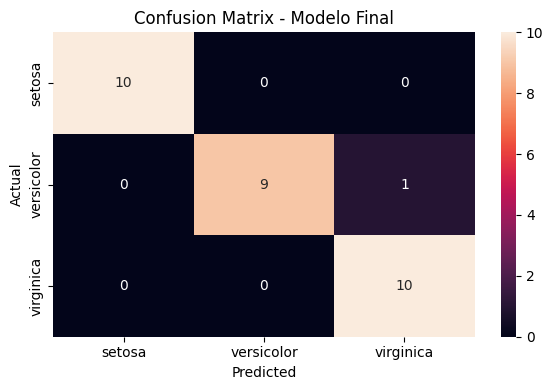

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



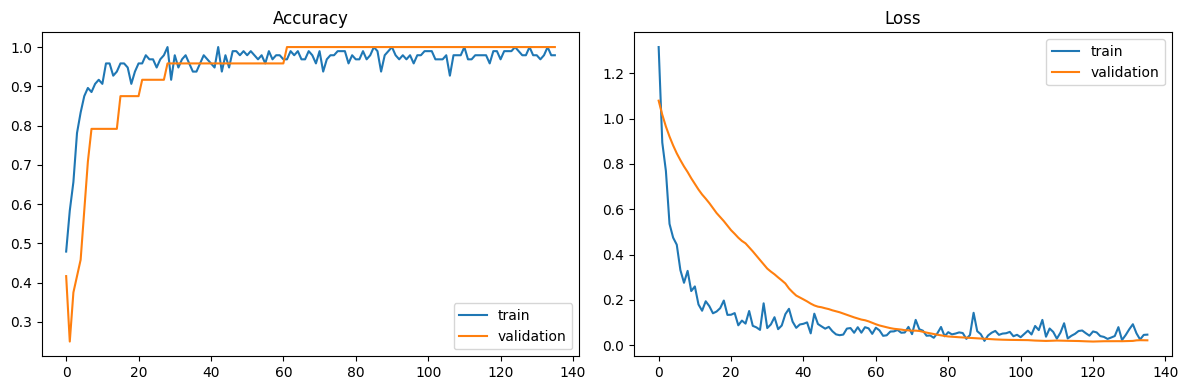

In [ ]:
# ==========================================
# 6. EVALUACIÓN COMPLETA
# ==========================================

y_pred_prob = final_model.predict(X_test_scaled)
y_pred = y_pred_prob.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Modelo Final')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=iris.target_names))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Parte 3: Explicabilidad con SHAP

**Problema:** las redes neuronales son cajas negras. Predicen bien pero no explican por qué.

**SHAP** (SHapley Additive exPlanations) responde:
> *¿Cuánto contribuyó cada feature a esta predicción concreta?*

Es fundamental en producción para auditar el modelo y poder explicar las decisiones.

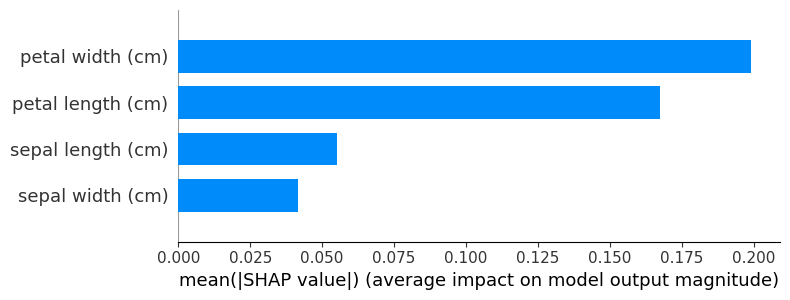


SHAP detallado para clase: versicolor


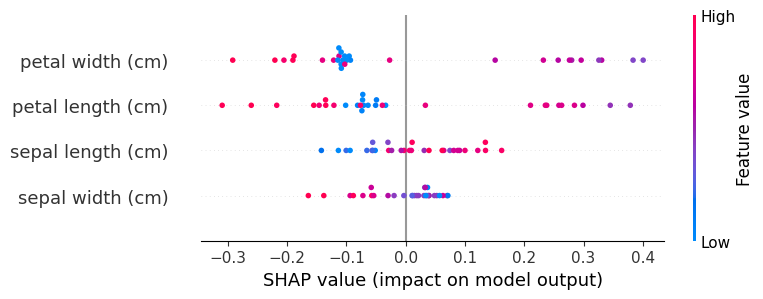

In [ ]:
# ==========================================
# 7. EXPLICABILIDAD CON SHAP
# ==========================================

background  = X_train_scaled[:50]
explainer   = shap.DeepExplainer(final_model, background)
shap_values = explainer.shap_values(X_test_scaled)
# shap_values: (n_ejemplos, 4 features, 3 clases)

feature_names = list(iris.feature_names)

# Separamos por clase: cada una queda (n_ejemplos, 4)
shap_setosa     = shap_values[:, :, 0]
shap_versicolor = shap_values[:, :, 1]
shap_virginica  = shap_values[:, :, 2]

# Gráfico 1: importancia global (promedio entre las 3 clases)
shap_global = np.abs(shap_values).mean(axis=2)  # → (n_ejemplos, 4)

shap.summary_plot(
    shap_global,
    X_test_scaled,
    feature_names=feature_names,
    plot_type='bar',
    show=True
)

# Gráfico 2: detalle para versicolor
print('\nSHAP detallado para clase: versicolor')
shap.summary_plot(
    shap_versicolor,
    X_test_scaled,
    feature_names=feature_names,
    show=True
)

## Parte 4: Guardar y cargar el pipeline

En producción un modelo no se re-entrena cada vez que alguien lo usa.
Se guarda entrenado y se carga cuando llega un dato nuevo.

Guardamos dos cosas por separado:
- El **scaler** (`joblib`): necesario para transformar datos nuevos exactamente igual que los de entrenamiento.
- El **modelo Keras** (`.keras`): pesos y arquitectura.

In [ ]:
# ==========================================
# 8. GUARDAR EL PIPELINE
# ==========================================

joblib.dump(scaler, 'iris_scaler.pkl')
final_model.save('iris_model.keras')

print('Guardado: iris_scaler.pkl')
print('Guardado: iris_model.keras')

Guardado: iris_scaler.pkl
Guardado: iris_model.keras


In [ ]:
# ==========================================
# 9. CARGAR EL PIPELINE (simular deploy)
# ==========================================

# En producción esto estaría en otro archivo / servicio
loaded_scaler = joblib.load('iris_scaler.pkl')
loaded_model  = tf.keras.models.load_model('iris_model.keras')

print('Modelo y scaler cargados exitosamente.\n')

# ==========================================
# 10. INFERENCIA SOBRE DATOS NUEVOS
# ==========================================

# 3 flores nuevas: (sepal_len, sepal_wid, petal_len, petal_wid)
nuevas_flores = np.array([
    [5.1, 3.5, 1.4, 0.2],  # debería ser setosa
    [6.0, 2.9, 4.5, 1.5],  # debería ser versicolor
    [6.7, 3.1, 5.6, 2.4],  # debería ser virginica
])

# Paso 1: escalar (transform, nunca fit_transform sobre datos nuevos)
nuevas_scaled = loaded_scaler.transform(nuevas_flores)

# Paso 2: predecir
probs       = loaded_model.predict(nuevas_scaled, verbose=0)
clases_pred = probs.argmax(axis=1)

# Paso 3: mostrar resultados
print('Resultados de inferencia:')
print('-' * 55)
for i, (pred, prob) in enumerate(zip(clases_pred, probs)):
    nombre    = iris.target_names[pred]
    confianza = prob[pred] * 100
    print(f'Flor {i+1}: {nombre:12s}  (confianza: {confianza:.1f}%)')
    print(f'         Probabilidades → {dict(zip(iris.target_names, np.round(prob, 3)))}')

Modelo y scaler cargados exitosamente.

Resultados de inferencia:
-------------------------------------------------------
Flor 1: setosa        (confianza: 99.9%)
         Probabilidades → {np.str_('setosa'): np.float32(0.999), np.str_('versicolor'): np.float32(0.001), np.str_('virginica'): np.float32(0.0)}
Flor 2: versicolor    (confianza: 98.2%)
         Probabilidades → {np.str_('setosa'): np.float32(0.002), np.str_('versicolor'): np.float32(0.982), np.str_('virginica'): np.float32(0.016)}
Flor 3: virginica     (confianza: 100.0%)
         Probabilidades → {np.str_('setosa'): np.float32(0.0), np.str_('versicolor'): np.float32(0.0), np.str_('virginica'): np.float32(1.0)}


---

## Resumen del nivel

| Técnica | Qué resuelve |
|---|---|
| CV sobre red neuronal | Estimación confiable del desempeño real |
| Optuna | Encuentra los mejores hiperparámetros sin hacerlo a mano |
| SHAP | Explica por qué el modelo toma cada decisión |
| `joblib` + `.keras` | El modelo puede vivir fuera del notebook |
| Inferencia sobre datos nuevos | Simula cómo se usaría en una app real |

## ¿Qué vendría después?

- Servir el modelo como API REST con **FastAPI** + **Docker**
- Monitorear data drift en producción con **Evidently**
- Pipelines de reentrenamiento automático